# Activation Foil Analysis: FLiBe 1L BABY Run #1

This notebook processes the calibration data from HPGe detectors to energy calibrate the detectors and determine total detector efficiencies. Then, NaI measurements of activation foils irradiated during the run with a D-T neutron (14.1 MeV) generator are used to determine the average neutron rate during the run. 

## Obtaining the Data
First, the NaI detector measurement data is obtained from Zenodo and extracted

In [1]:
# parameters

## keep this if statement for ci and process workflows
if 'download_from_raw' not in globals() and 'download_from_raw' not in locals():
    download_from_raw = False

In [2]:
import numpy as np
from datetime import datetime
import json
from libra_toolbox.neutron_detection.activation_foils import compass
from matplotlib import pyplot as plt

In [3]:
from process_foil_data import get_data

detector_type = "NaI"
check_source_measurements, background_meas, foil_measurements = get_data(download_from_raw=download_from_raw,
                                                                         h5_filename="activation_data.h5",
                                                                         detector_type=detector_type)

Available detector types:  ['NaI']
Read in properties of Zirconium Packet #3 foil
Read in properties of Zirconium Packet #11 foil
Read in properties of Niobium Packet #10 foil
Read in properties of Niobium Packet #13 foil
Processing Background from h5 file...
Processing Co60 Count 1 from h5 file...
Processing Co60 Count 2 from h5 file...
Processing Cs137 Count 1 from h5 file...
Processing Cs137 Count 2 from h5 file...
Processing Na22 Count 1 from h5 file...
Processing Na22 Count 2 from h5 file...
Processing Niobium Packet #10 Count 1 from h5 file...
Processing Niobium Packet #10 Count 2 from h5 file...
Processing Niobium Packet #13 Count 1 from h5 file...
Processing Niobium Packet #13 Count 2 from h5 file...
Processing Zirconium Packet #11 Count 1 from h5 file...
Processing Zirconium Packet #11 Count 2 from h5 file...
Processing Zirconium Packet #3 Count 1 from h5 file...
Processing Zirconium Packet #3 Count 2 from h5 file...


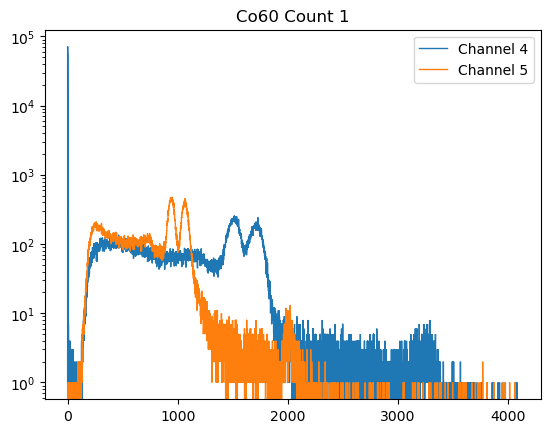

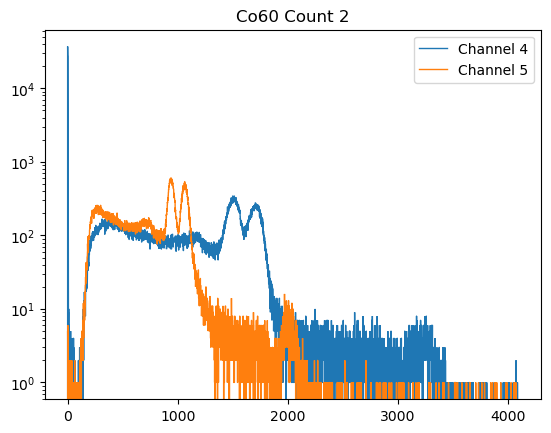

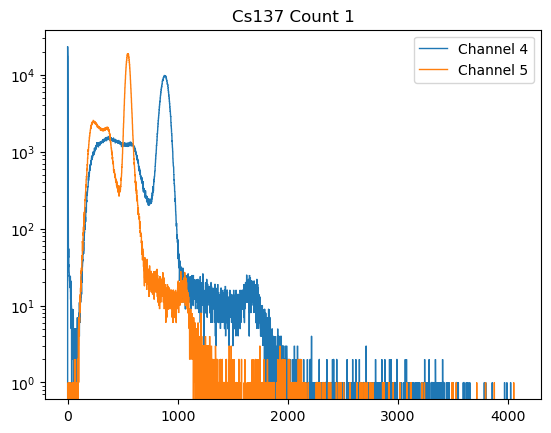

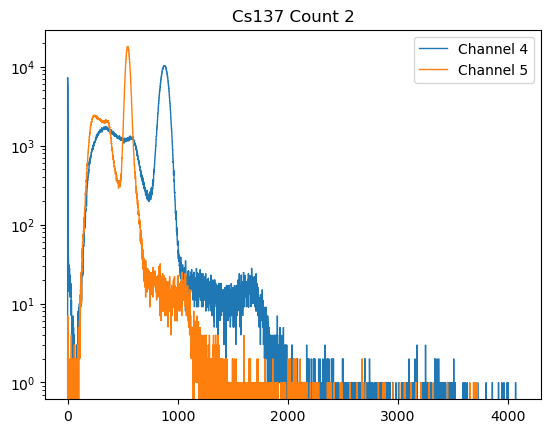

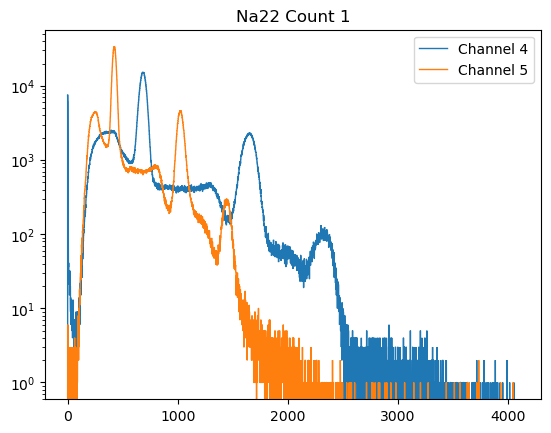

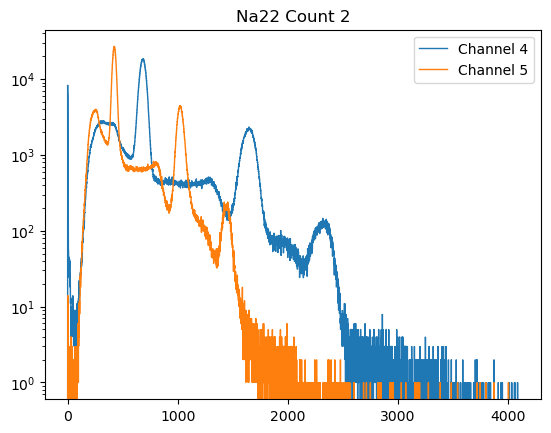

In [4]:
channels = [4, 5]
for name, measurement in check_source_measurements.items():
    fig, ax = plt.subplots()
    for ch in channels:
        det = measurement.get_detector(ch)
        hist, xvals = det.get_energy_hist()
        ax.stairs(hist, xvals, label=f'Channel {ch}')
    ax.legend()
    ax.set_title(name)
    ax.set_yscale('log')
    

## Energy Calibration

Using gamma check sources like Co-60 and Cs-137, the characteristic photon peaks from these sources are used to convert the digitizer channel bins into energy (keV) bins

Calibrating channel 4...
Using custom peak finding parameters from kwargs:  {'start_index': 300}
Using custom peak finding parameters from kwargs:  {'start_index': 300}
Calibrating channel 5...
Using custom peak finding parameters from kwargs:  {'start_index': 300}
Using custom peak finding parameters from kwargs:  {'start_index': 300}


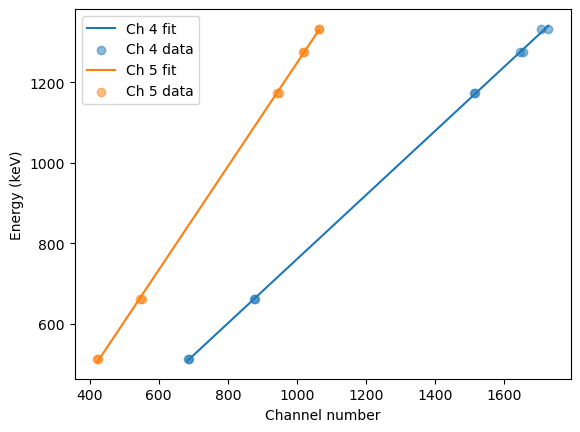

In [5]:
calibration_coeffs = {}


for ch in channels:
    print(f"Calibrating channel {ch}...")
    # mn54_hist = check_source_measurements["Mn54 Count 1"].get_detector(ch).get_energy_hist()[0]
    peak_kwargs = {'Na22': {'start_index': 300,
                        # 'prominence': mn54_hist[100:].max() * 0.1,
                        # 'width': [1, 50],
                        # 'height': mn54_hist[100:].max() * 0.1}
                    }
    }
    calibration_channels, calibration_energies = compass.get_calibration_data(
        check_source_measurements.values(),
        background_measurement=background_meas,
        channel_nb=ch,
        peak_kwargs=peak_kwargs
    )

    coeff = np.polyfit(calibration_channels, calibration_energies, 1)
    calibration_coeffs[ch] = coeff

    xs = np.linspace(
        calibration_channels[0],
        calibration_channels[-1],
    )
    plt.plot(
        xs,
        np.polyval(coeff, xs),
        label=f"Ch {ch} fit",
    )
    plt.scatter(
        calibration_channels,
        calibration_energies,
        label=f"Ch {ch} data",
        alpha=0.5,
    )
    plt.xlabel("Channel number")
    plt.ylabel("Energy (keV)")
    plt.legend()
plt.show()

## Detector Efficiency

Using these same check-sources, each with a known activity, an efficiency curve for each detector is calculated. 

Two types of efficiency curves are shown: 
1. Exponent of sum of logarithms (used in https://doi.org/10.2172/1524045): $ y = \exp(\sum_{i=0}^n a_n \log(E)^i) $

2. Polynomial fit (3rd order): $ y = \sum_{i=0}^n a_n E^i $

**Only the polynomal fit is currently implemented in libra-toolbox, so that is the curve that will be used to calculate the efficiency of the detectors at measuring the activity of the activation foil peaks.**

In [6]:
for name, measurement in check_source_measurements.items():
    for detector in measurement.detectors:
        dead_time_fraction = 1 - detector.live_count_time / detector.real_count_time
        print(f"{name} Ch {detector.channel_nb} \n\t Live time: {detector.live_count_time} s \n\t Real time: {detector.real_count_time} s")
        print(f"\t Dead time fraction: {dead_time_fraction:.2%}")

Co60 Count 1 Ch 4 
	 Live time: 305.686 s 
	 Real time: 306.139 s
	 Dead time fraction: 0.15%
Co60 Count 1 Ch 5 
	 Live time: 305.968 s 
	 Real time: 306.137 s
	 Dead time fraction: 0.06%
Co60 Count 2 Ch 4 
	 Live time: 394.553 s 
	 Real time: 394.894 s
	 Dead time fraction: 0.09%
Co60 Count 2 Ch 5 
	 Live time: 394.69 s 
	 Real time: 394.892 s
	 Dead time fraction: 0.05%
Cs137 Count 1 Ch 4 
	 Live time: 119.646 s 
	 Real time: 121.284 s
	 Dead time fraction: 1.35%
Cs137 Count 1 Ch 5 
	 Live time: 119.814 s 
	 Real time: 121.284 s
	 Dead time fraction: 1.21%
Cs137 Count 2 Ch 4 
	 Live time: 119.697 s 
	 Real time: 121.3 s
	 Dead time fraction: 1.32%
Cs137 Count 2 Ch 5 
	 Live time: 119.91 s 
	 Real time: 121.3 s
	 Dead time fraction: 1.15%
Na22 Count 1 Ch 4 
	 Live time: 122.508 s 
	 Real time: 125.136 s
	 Dead time fraction: 2.10%
Na22 Count 1 Ch 5 
	 Live time: 122.373 s 
	 Real time: 125.135 s
	 Dead time fraction: 2.21%
Na22 Count 2 Ch 4 
	 Live time: 117.691 s 
	 Real time: 120.62

In [7]:
def eff_curve_func(E, *a):
    exponent_term = 0
    for i,a_n in enumerate(a):
        exponent_term += a_n * (np.log(E) ** i)
    return np.exp(exponent_term)

/var/folders/8l/th_q6c756gb0yy2fvkvdjntr0000gn/T/ipykernel_40157/3936937588.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


[1170.33538226 1339.97339743]
Fitted parameters: [ 1.43851654e+02 -9.69129368e-02  2.00913070e+02  1.16807700e+03
  4.03806896e+01  1.69659579e+02  1.32837912e+03  4.30234973e+01]

[1169.53895966 1322.45210009]
Fitted parameters: [ 2.00857823e+02 -1.36411007e-01  2.69640436e+02  1.16493662e+03
  4.07921026e+01  2.29878149e+02  1.32459427e+03  4.21220639e+01]

[664.6070272]
Fitted parameters: [ 1.72390353e+03 -2.04379778e+00  9.44537962e+03  6.66354138e+02
  2.65062768e+01]

[662.21775938]
Fitted parameters: [ 1.70555643e+03 -2.02532245e+00  1.00532153e+04  6.63885308e+02
  2.63654718e+01]

[ 511.69388677 1282.63096977]
[np.float64(511.69388677415066)]
Fitted parameters: [ 2.93310750e+03 -3.66476725e+00  1.43383734e+04  5.09071719e+02
 -2.17844952e+01]
[np.float64(1282.6309697653733)]
Fitted parameters: [ 8.79387221e+02 -5.59788686e-01  2.13457490e+03  1.27641643e+03
  4.21558203e+01]

[ 508.50819635 1273.8703211 ]
[np.float64(508.508196348567)]
Fitted parameters: [ 3.15544375e+03 -4.00

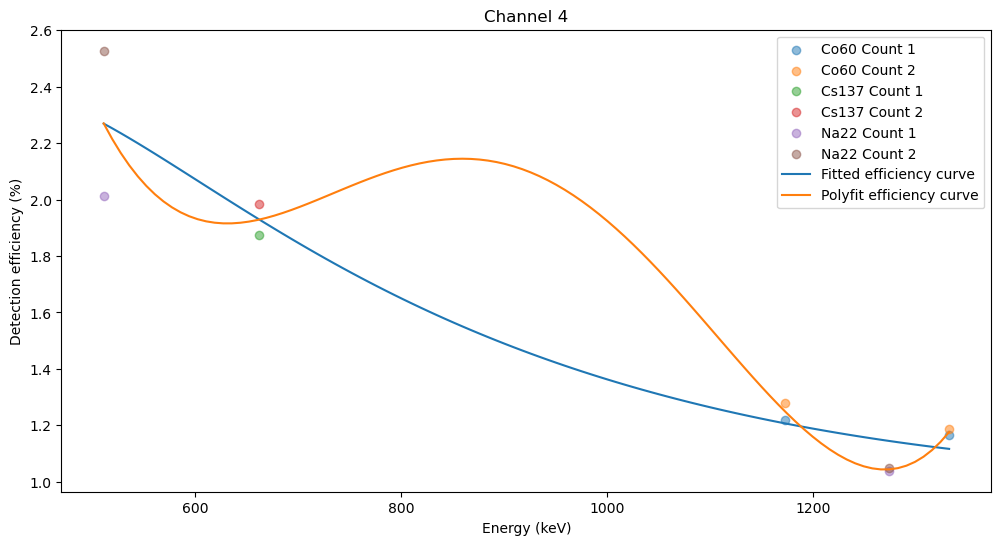

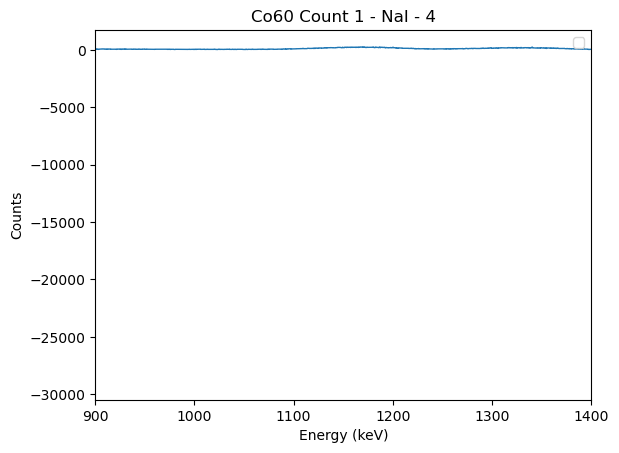

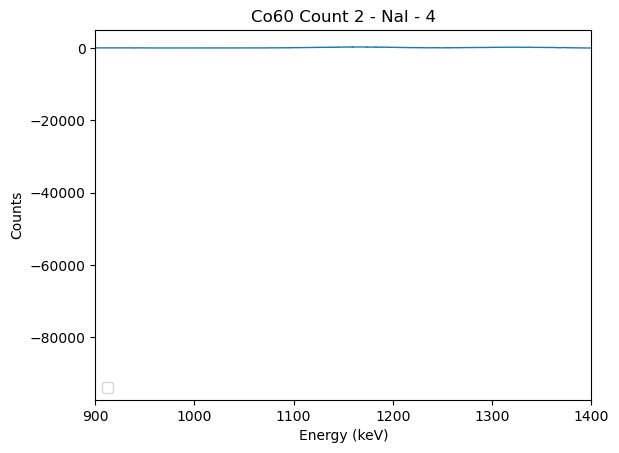

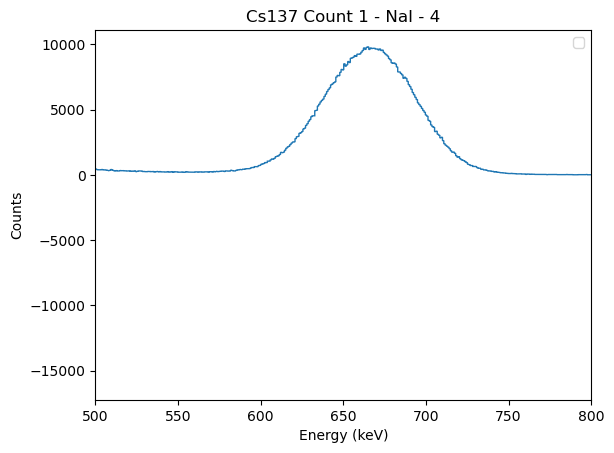

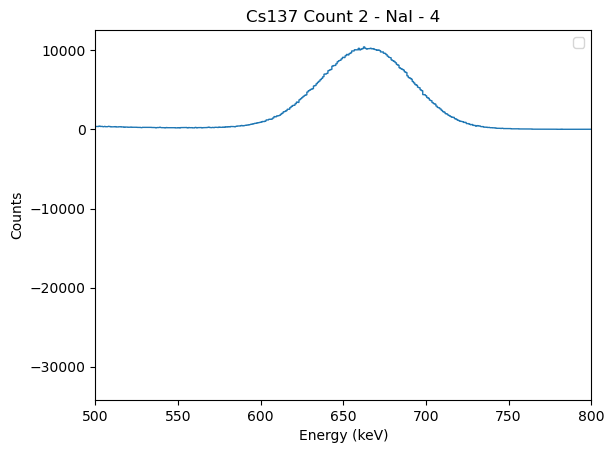

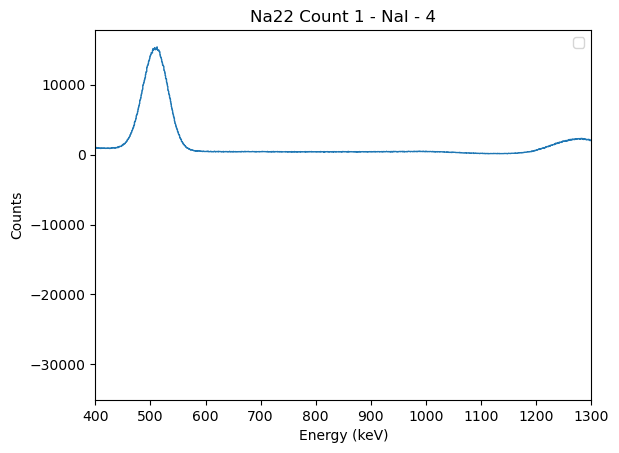

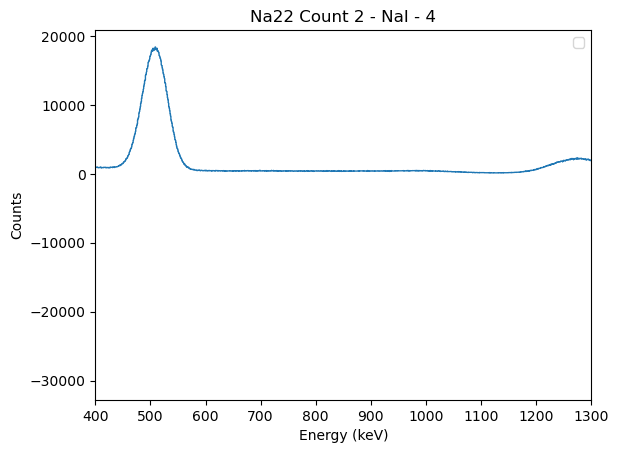

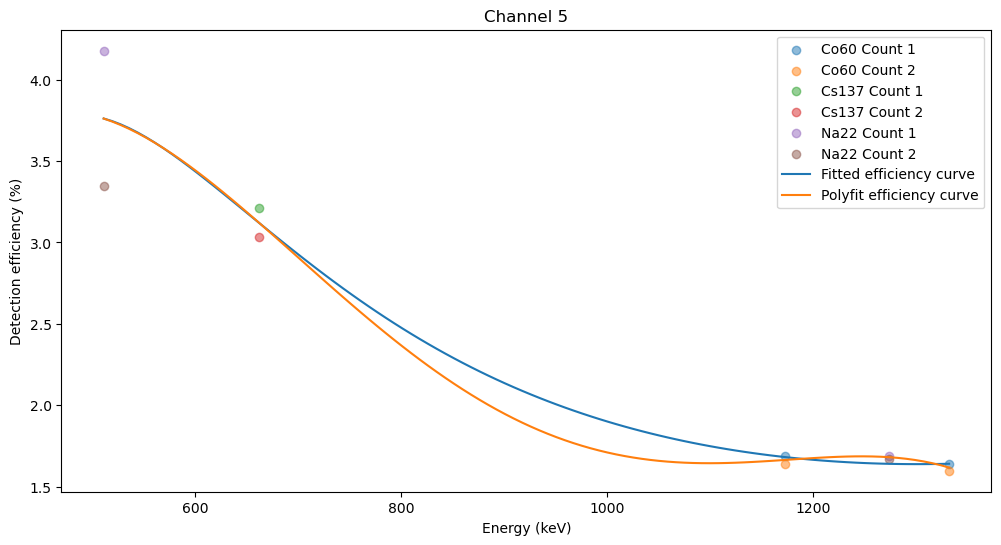

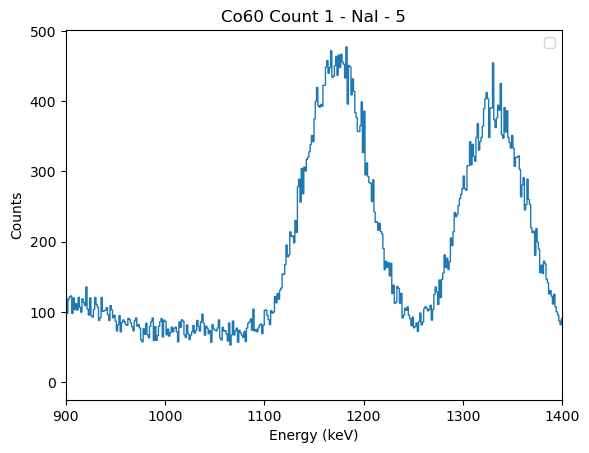

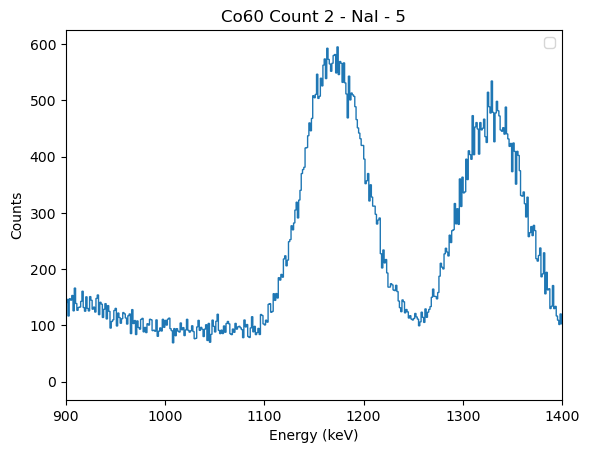

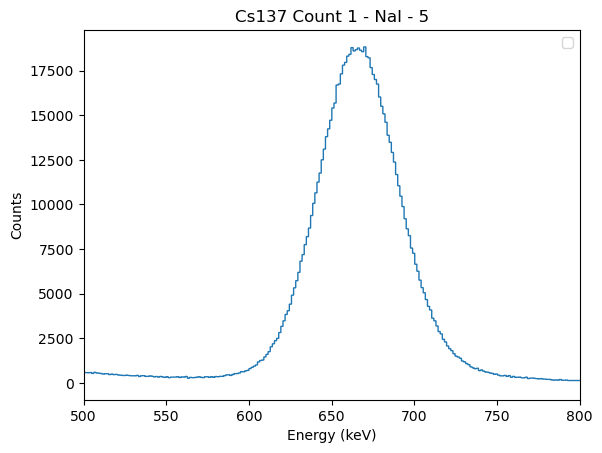

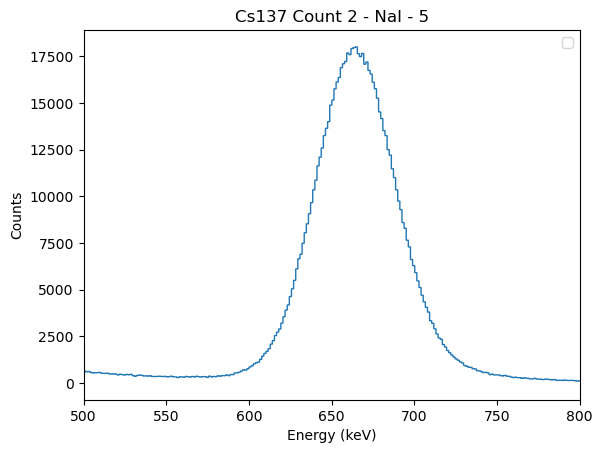

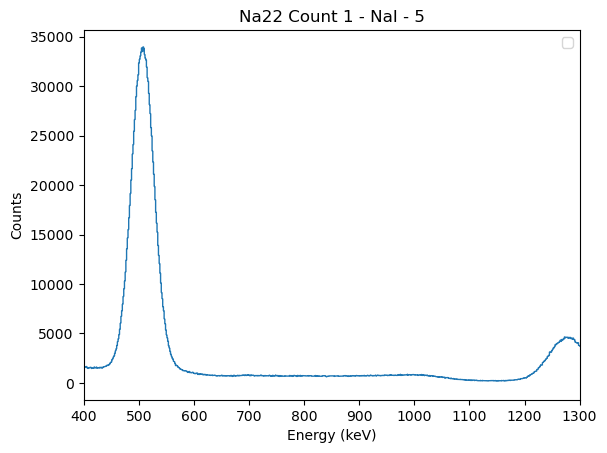

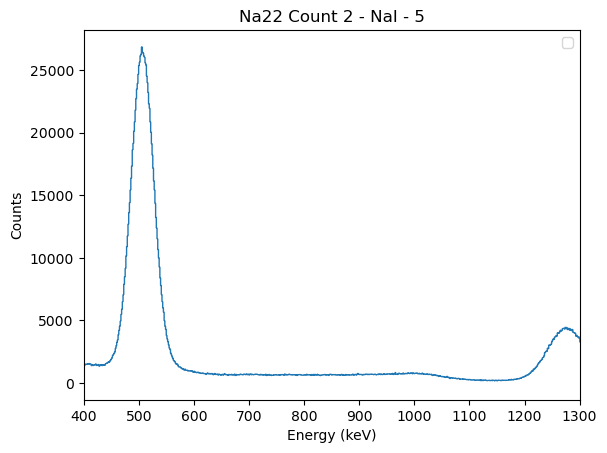

In [8]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

channels = []
efficiency_coeffs = {}
exp_efficiency_coeffs = {}
measurement = list(check_source_measurements.values())[0]

# search_widths = np.arange(20, 50, 2)
# for search_width in search_widths:
search_width = 300
threshold_overlap = 200
for detector in measurement.detectors:
    channels.append(detector.channel_nb)

xlim_dict = {
    'Ba133': [100, 500],
    'Co60': [900, 1400],
    'Cs137': [500, 800],
    'Mn54': [600, 900],
    'Na22': [400, 1300],
}

for channel_nb in channels:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))

    background_detector = background_meas.get_detector(channel_nb)
    energies = []
    efficiencies = []
    for name, measurement in check_source_measurements.items():
        check_source_detector = measurement.get_detector(channel_nb)
        hist, bin_edges = check_source_detector.get_energy_hist_background_substract(background_detector, bins=None)
        calibrated_bin_edges = np.polyval(calibration_coeffs[channel_nb], bin_edges)

        # plot the histogram
        fig2,ax2 = plt.subplots()
        ax2.stairs(hist, calibrated_bin_edges)
        # ax2.set_xlim(left=0, right=500)

        # See how well calibrated peaks match expected energies
        expected_energies = measurement.check_source.nuclide.energy
        for energy in expected_energies:
            lower_ind = np.argmin(np.abs((energy - search_width) - calibrated_bin_edges))
            upper_ind = np.argmin(np.abs((energy + search_width) - calibrated_bin_edges))
            hist_search = hist[lower_ind:upper_ind]

            peaks, peak_params = find_peaks(hist_search, height=np.max(hist_search) * 0.5)

        # print('notebook search_width:', search_width, ' threshold_overlap:', threshold_overlap)

        # uncalibrated = np.array(
        #             measurement.check_source.nuclide._uncalibrated_measured_energies.get(channel_nb, []),
        #             dtype=float
        #         )
        # calibrated_ergs = np.polyval(calibration_coeffs[channel_nb], uncalibrated)


        ax2.set_xlabel("Energy (keV)")
        ax2.set_ylabel("Counts")
        ax2.set_title(f"{measurement.name} - {measurement.detector_type} - {channel_nb}")
        ax2.legend()
        nuclide = name.split()[0]
        if nuclide in xlim_dict:
            ax2.set_xlim(left=xlim_dict[nuclide][0], right=xlim_dict[nuclide][1])
        else:
            ax2.set_xlim(left=0, right=1500)
        
        efficiency = measurement.compute_detection_efficiency(
            background_measurement=background_meas,
            calibration_coeffs=calibration_coeffs[channel_nb],
            channel_nb=channel_nb,
            search_width=search_width,
            threshold_overlap=threshold_overlap,
            # summing_method='sum_gaussian',
            summing_method='sum_histogram'
        )
        print("\n" + "=" * 40)

        energies += measurement.check_source.nuclide.energy
        efficiencies += list(efficiency)
        ax.scatter(
            measurement.check_source.nuclide.energy,
            efficiency * 100,
            label=name,
            alpha=0.5
        )

    # Sort energies and efficiencies for fitting
    sorted_indices = np.argsort(energies)
    energies = np.array(energies)[sorted_indices]
    efficiencies = np.array(efficiencies)[sorted_indices]
    print(f"Ch {channel_nb} \n\t Energies: {energies}, \n\t Efficiencies: {efficiencies}")

    # Fit the efficiency curve
    popt, pcov = curve_fit(
        eff_curve_func,
        energies,
        efficiencies,
        p0=[-1, 1, 0, 0],
    )

    exp_efficiency_coeffs[channel_nb] = popt

    poly_coeff = np.polyfit(energies, efficiencies, 4)
    efficiency_coeffs[channel_nb] = poly_coeff
    xs = np.linspace(
        energies[0],
        energies[-1],
        100,
    )
    ax.plot(
        xs,
        eff_curve_func(xs, *popt) * 100,
        label="Fitted efficiency curve",
    )

    ax.plot(
        xs,
        np.polyval(poly_coeff, xs) * 100,
        label="Polyfit efficiency curve",
    )
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Detection efficiency (%)")
    ax.set_title(f"Channel {channel_nb}")
    ax.legend()
    # plt.ylim(bottom=0)
    print(popt)
plt.show()

## Calculating average neutron rate from activation foils

First, the irradiation schedule and the foil information is collected.

In [9]:
all_neutron_rates = []
all_neutron_rates_err = []

## Irradiation Time

In [10]:
from process_foil_data import irradiations
print("Irradiation schedule from process_foil_data.py:")
for i, irrad in enumerate(irradiations):
    print(f"  {i+1}. {irrad['t_on']} - {irrad['t_off']}")
# irradiations = [
#     {'t_on': 0.0, 't_off': 100.0},
#     {'t_on': 150.0, 't_off': 300.0}]

Irradiation schedule from process_foil_data.py:
  1. 0.0 - 24900.0
  2. 24960.0 - 25440.0
  3. 25680.0 - 29340.0
  4. 29400.0 - 30120.0
  5. 30180.0 - 30420.0


### Zirconium Packet #3 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 is formed from the Zr-90(n,2n) reaction, which has a threshold energy of ~12 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #3 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [11]:
# Evaluate efficiency function at the energies of interest for each channel
print("Zirconium efficiencies:")
zr_energy = foil_measurements["Zirconium Packet #3"]["foil"].reaction.product.energy[0]
for ch in channels:
    efficiency = eff_curve_func(zr_energy, *exp_efficiency_coeffs[ch])
    print(f"\tChannel {ch}: {efficiency}")

print("Niobium efficiencies:")
nb_energy = foil_measurements["Niobium Packet #10"]["foil"].reaction.product.energy[0]
for ch in channels:
    efficiency = eff_curve_func(nb_energy, *exp_efficiency_coeffs[ch])
    print(f"\tChannel {ch}: {efficiency}")


Zirconium efficiencies:
	Channel 4: 0.014770996333731651
	Channel 5: 0.021111181552818156
Niobium efficiencies:
	Channel 4: 0.014428146119251195
	Channel 5: 0.020445904449478372


In [14]:
from process_foil_data import calculate_neutron_rate_from_foil

foil_name = "Zirconium Packet #3"
efficiency_coeffs = {ch: None for ch in calibration_coeffs.keys()} # Use the efficiency function definition
neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations,
                                                                    efficiency_function=eff_curve_func,
                                                                    efficiency_function_args=exp_efficiency_coeffs)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])


[909.15]
Fitted parameters: [ 3.79565184e+02 -3.28807667e-01  1.28944125e+03  8.94754407e+02
  3.19485986e+01]
[909.15]
Fitted parameters: [ 6.09943357e+02 -5.12033439e-01  2.42505275e+03  9.03910755e+02
  2.74641424e+01]
[909.15]
Fitted parameters: [ 9.90631700e+01 -9.13902276e-02  3.65632927e+02  8.83848981e+02
  3.30268868e+01]
[909.15]
Fitted parameters: [ 1.59754194e+02 -1.41200229e-01  7.08920854e+02  8.98839517e+02
  2.78162866e+01]
Count 1
	 Ch 4: Neutron rate: 7.150e+08 +/- 2.228e+06 n/s
	 Ch 5: Neutron rate: 8.080e+08 +/- 1.980e+06 n/s
Count 2
	 Ch 4: Neutron rate: 7.158e+08 +/- 4.120e+06 n/s
	 Ch 5: Neutron rate: 8.170e+08 +/- 3.680e+06 n/s


### Zirconium Packet #11 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 is formed from the Zr-90(n,2n) reaction, which has a threshold energy of 12.1 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #1 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [15]:
foil_name = "Zirconium Packet #11"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations,
                                                                    efficiency_function=eff_curve_func,
                                                                    efficiency_function_args=exp_efficiency_coeffs)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

[909.15]
Fitted parameters: [ 6.77833777e+01 -5.96063768e-02  2.52120611e+02  8.86320287e+02
  3.16349654e+01]
[909.15]
Fitted parameters: [ 1.06686297e+02 -9.26971415e-02  4.65860966e+02  8.98449514e+02
  2.75463876e+01]
[909.15]
Fitted parameters: [ 3.07920353e+02 -2.87995112e-01  1.11517656e+03  8.80983439e+02
  3.32539552e+01]
[909.15]
Fitted parameters: [ 4.68949083e+02 -4.10987963e-01  2.14808208e+03  8.98006322e+02
  2.77434251e+01]
Count 1
	 Ch 4: Neutron rate: 5.243e+08 +/- 3.714e+06 n/s
	 Ch 5: Neutron rate: 5.898e+08 +/- 3.293e+06 n/s
Count 2
	 Ch 4: Neutron rate: 5.250e+08 +/- 1.724e+06 n/s
	 Ch 5: Neutron rate: 5.896e+08 +/- 1.528e+06 n/s


In [16]:
foil_name = "Niobium Packet #10"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations,
                                                                    efficiency_function=eff_curve_func,
                                                                    efficiency_function_args=exp_efficiency_coeffs)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

[934.44]
Fitted parameters: [ 7.86431527e+01 -7.08985110e-02  3.21114024e+02  9.05463503e+02
  3.34257757e+01]
[934.44]
Fitted parameters: [ 1.26424471e+02 -1.07302953e-01  6.15834630e+02  9.21808422e+02
  2.84203939e+01]
[934.44]
Fitted parameters: [ 9.36714084e+01 -8.31764736e-02  3.58396876e+02  8.98149397e+02
  3.26921333e+01]
[934.44]
Fitted parameters: [ 1.38705171e+02 -1.18200256e-01  6.61036877e+02  9.20243902e+02
  2.77507001e+01]
Count 1
	 Ch 4: Neutron rate: 8.864e+08 +/- 5.411e+06 n/s
	 Ch 5: Neutron rate: 1.019e+09 +/- 4.870e+06 n/s
Count 2
	 Ch 4: Neutron rate: 9.135e+08 +/- 5.338e+06 n/s
	 Ch 5: Neutron rate: 9.841e+08 +/- 4.596e+06 n/s


In [17]:
foil_name = "Niobium Packet #13"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations,
                                                                    efficiency_function=eff_curve_func,
                                                                    efficiency_function_args=exp_efficiency_coeffs)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

[934.44]
Fitted parameters: [ 2.92055963e+02 -2.58118403e-01  1.17127232e+03  9.09680726e+02
  3.36938422e+01]
[934.44]
Fitted parameters: [ 5.18174421e+02 -4.22161683e-01  2.27473498e+03  9.24318351e+02
  2.80038449e+01]
[934.44]
Fitted parameters: [ 7.09493687e+02 -5.90379658e-01  2.30451990e+03  9.02300780e+02
  3.33900466e+01]
[934.44]
Fitted parameters: [ 9.66122451e+02 -8.08159634e-01  4.45460769e+03  9.23144439e+02
  2.82318176e+01]
Count 1
	 Ch 4: Neutron rate: 5.478e+08 +/- 1.744e+06 n/s
	 Ch 5: Neutron rate: 6.327e+08 +/- 1.586e+06 n/s
Count 2
	 Ch 4: Neutron rate: 5.726e+08 +/- 1.306e+06 n/s
	 Ch 5: Neutron rate: 6.272e+08 +/- 1.119e+06 n/s


### Averaging foil results

The average of the neutron rates of the Niobium and Zirconium foil packets is calculated and added to the processed_data.json file. 

In [18]:
average_neutron_rate = np.mean(all_neutron_rates)
# average_neutron_rate_err = np.sqrt(np.sum(np.array(all_neutron_rates_err) ** 2)) / len(all_neutron_rates_err)
average_neutron_rate_err = np.std(all_neutron_rates, ddof=1)  # Use ddof=1 for sample standard deviation

print(f"Average neutron rate: {average_neutron_rate:.3e} ± {average_neutron_rate_err:.3e} n/s")

total_irradiation_time = sum(irrad['t_off'] - irrad['t_on'] for irrad in irradiations)
print(f"\nTotal irradiation time (from schedule): {total_irradiation_time:.2f} seconds")
print("Total neutrons (approximate): {:.3e} +/- {:.2e}".format(
      total_irradiation_time * average_neutron_rate,
      total_irradiation_time * average_neutron_rate_err))

Average neutron rate: 7.262e+08 ± 1.514e+08 n/s

Total irradiation time (from schedule): 30000.00 seconds
Total neutrons (approximate): 2.178e+13 +/- 4.54e+12


In [19]:
processed_data_file = "../../data/processed_data.json"

processed_data = {
    "neutron_rate_used_in_model": {
        "value":average_neutron_rate,
        "error": average_neutron_rate_err,
        "unit": "neutron / second"
    }
}

try:
    with open(processed_data_file, "r") as f:
        existing_data = json.load(f)
except FileNotFoundError:
    print(f"Processed data file not found, creating it in {processed_data_file}")
    existing_data = {}

existing_data.update(processed_data)

with open(processed_data_file, "w") as f:
    json.dump(existing_data, f, indent=4)

print(f"Processed data stored in {processed_data_file}")

Processed data file not found, creating it in ../../data/processed_data.json
Processed data stored in ../../data/processed_data.json
